# Assignment 5
## Submitted by Chaitanya Jindal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,order_id,date,region,category,product,units_sold,unit_price,discount,revenue,customer_age,customer_gender,payment_mode,returns
0,1001,2023-01-03,North,Electronics,Laptop,2,55000,0.05,104500,34,Male,Credit Card,0
1,1002,2023-01-05,South,Clothing,Shirt,10,899,0.10,8091,22,Female,UPI,1
2,1003,2023-01-07,East,Furniture,Chair,3,4500,0.00,13500,45,Male,Cash,0
3,1004,2023-01-09,West,Electronics,Smartphone,5,22000,0.08,101200,29,Female,Debit Card,0
4,1005,2023-01-12,North,Grocery,Rice,20,250,0.00,5000,38,Female,Cash,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         120 non-null    int64  
 1   date             120 non-null    str    
 2   region           120 non-null    str    
 3   category         120 non-null    str    
 4   product          120 non-null    str    
 5   units_sold       120 non-null    int64  
 6   unit_price       120 non-null    int64  
 7   discount         120 non-null    float64
 8   revenue          120 non-null    int64  
 9   customer_age     120 non-null    int64  
 10  customer_gender  120 non-null    str    
 11  payment_mode     120 non-null    str    
 12  returns          120 non-null    int64  
dtypes: float64(1), int64(6), str(6)
memory usage: 12.3 KB


In [4]:
df.describe()

,order_id,units_sold,unit_price,discount,revenue,customer_age,returns
count,120.000000,120.0000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,1060.500000,9.7250,13741.133333,0.054500,47919.725000,36.591667,0.108333
std,34.785054,9.3404,16893.611385,0.042005,60002.071767,9.938885,0.312104
min,1001.000000,1.0000,80.000000,0.000000,2400.000000,21.000000,0.000000
25%,1030.750000,3.0000,899.000000,0.000000,10181.000000,28.000000,0.000000
50%,1060.500000,6.0000,4500.000000,0.060000,22500.000000,35.500000,0.000000
75%,1090.250000,11.2500,22000.000000,0.100000,63090.000000,44.000000,0.000000
max,1120.000000,45.0000,55000.000000,0.120000,313500.000000,58.000000,1.000000


In [5]:
df["date"] = pd.to_datetime(df["date"])
df['month'] = df['date'].dt.month_name()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         120 non-null    int64         
 1   date             120 non-null    datetime64[us]
 2   region           120 non-null    str           
 3   category         120 non-null    str           
 4   product          120 non-null    str           
 5   units_sold       120 non-null    int64         
 6   unit_price       120 non-null    int64         
 7   discount         120 non-null    float64       
 8   revenue          120 non-null    int64         
 9   customer_age     120 non-null    int64         
 10  customer_gender  120 non-null    str           
 11  payment_mode     120 non-null    str           
 12  returns          120 non-null    int64         
 13  month            120 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(6), str(6)
me

#### Question 1: Line Plot (Monthly Revenue)

In [6]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

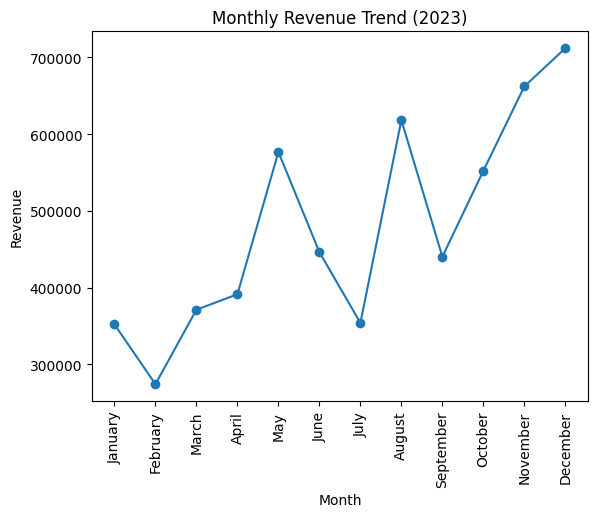

In [7]:
monthly_revenue = df.groupby('month')['revenue'].sum()
monthly_revenue = monthly_revenue.reindex(month_order)

plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title("Monthly Revenue Trend (2023)")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

##### The Sales surges in the Months of May, August, November and Decemeber, increasing respectively... Whereas there are certain are declines in the sales in the months of February, July, July and September

#### Question 2: Bar Chart (Revenue by Region)

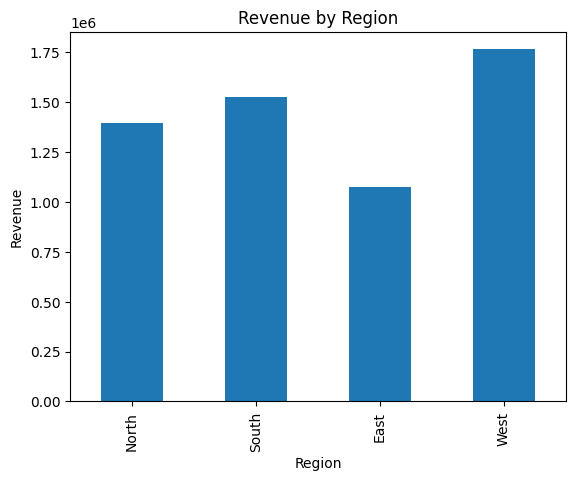

In [8]:
region_revenue = df.groupby('region')['revenue'].sum().reindex(df['region'].unique())

region_revenue.plot(kind='bar')
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

##### The revenue generated against the Regions is increasing as East < North < South < West...

#### Question 3: Stacked Bar Chart (Monthly Category Revenue)

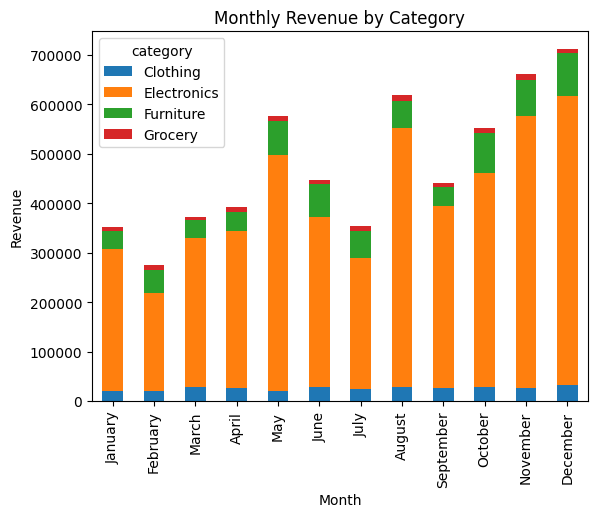

In [9]:
pivot_table = df.pivot_table(values='revenue', index='month', columns='category', aggfunc='sum')

pivot_table = pivot_table.reindex(month_order)

pivot_table.plot(kind='bar', stacked=True)
plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

##### The Electronics Sales are dominating the revenues in all the months across the year...

#### Question 4 Pie Chart (Category Share)

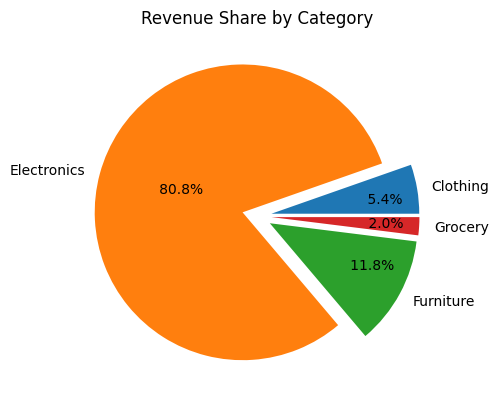

In [10]:
category_revenue = df.groupby('category')['revenue'].sum()
explode = [0.1, 0.1, 0.1, 0.1]
plt.pie(category_revenue, labels=category_revenue.index, autopct='%15.1f%%', explode=explode)
plt.title("Revenue Share by Category")
plt.show()

##### This is the pie chart showing the revenue share by category, where Electronics have contributed to the most revenue...

#### Question 5: Scatter Plot (Discount vs Revenue)

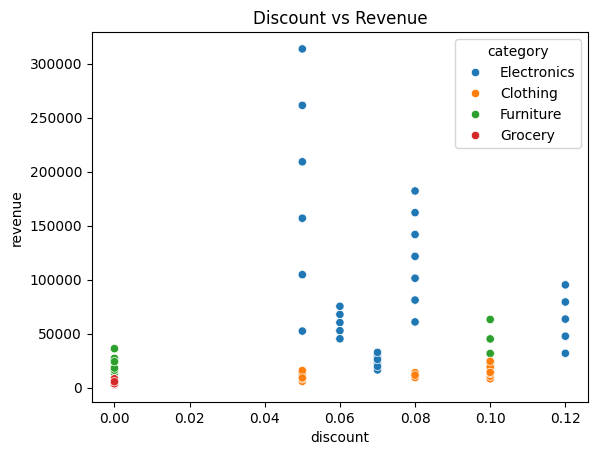

In [11]:
sns.scatterplot(x='discount', y='revenue', hue='category', data=df)
plt.title("Discount vs Revenue")
plt.show()

##### This is the scatter plot representing which categoiries have sold which amount items againt the discount percentage...

#### Question 6: Histogram (Customer Age)

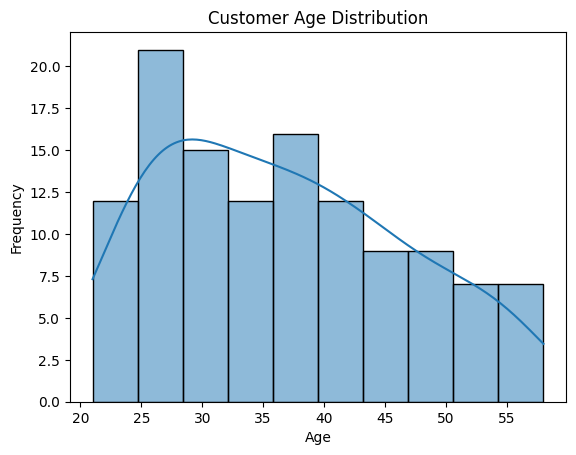

In [12]:
sns.histplot(df['customer_age'], bins=10, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

##### This shows the distribution of the customers frequency segregated into the group of their ages...

#### Question 7: Grouped Bar Chart (Revenue by Gender & Category)

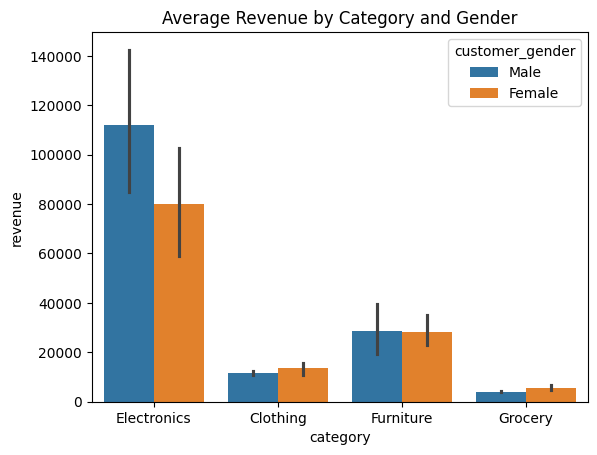

In [13]:
sns.barplot(x='category', y='revenue', hue='customer_gender', data=df)
plt.title("Average Revenue by Category and Gender")
plt.show()

##### This is the revenue from the category with the contrast of genders, like how much did each gender spent in each category...

#### Question 8: Boxplot & Violinplot

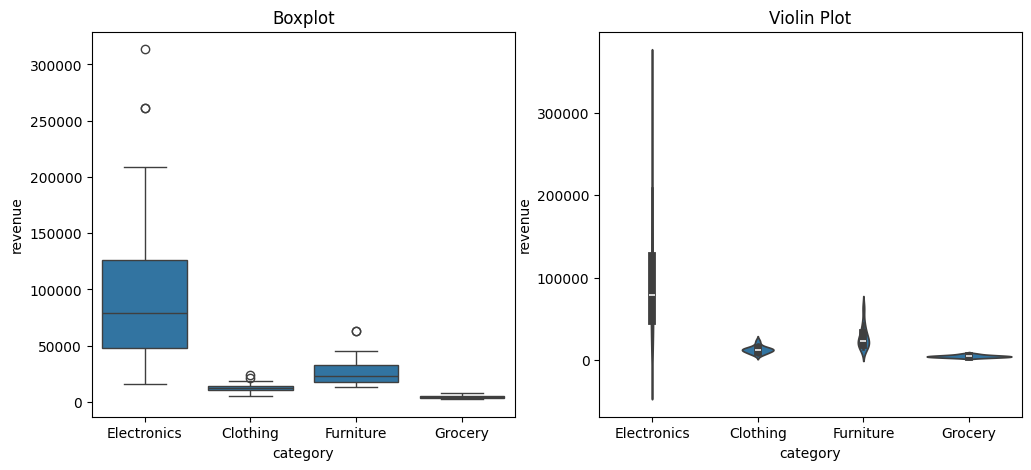

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='category', y='revenue', data=df)
plt.title("Boxplot")

plt.subplot(1,2,2)
sns.violinplot(x='category', y='revenue', data=df)
plt.title("Violin Plot")

plt.show()

##### This show the how densly the revenue generating items in each category are close to (in terms of their price or billing)...

#### Question 10: Countplot (Payment Mode)

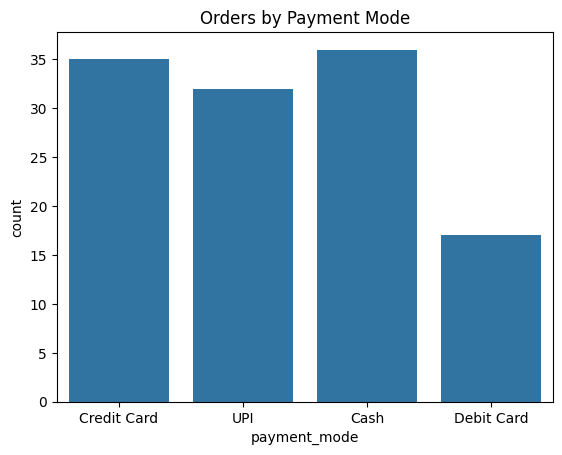

In [15]:
sns.countplot(x='payment_mode', data=df)
plt.title("Orders by Payment Mode")
plt.show()

##### This plot represents how many customers chose to pay by which means...

#### Question 11: KDE Plot (Revenue Distribution)

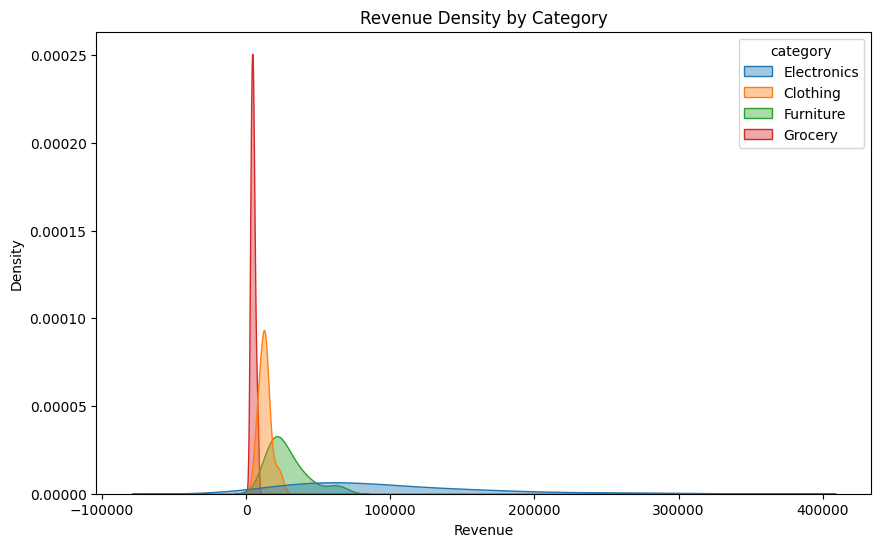

In [16]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='revenue', hue='category', fill=True, common_norm=False, alpha=0.4)
plt.title("Revenue Density by Category")
plt.xlabel("Revenue")
plt.ylabel("Density")
plt.show()

##### This graph shows how well the items bought against different categories are distributed in a normal graph...
- The Groceries are Leptokurtic i.e. everyone bought groceries biolling roughly the range...
- However, Clothing is more varianced, and so is furniture where everyone spent more varianced than each other...
- The Electronics are the most varianced, like it's not that everyone had same expenses, there's a huge variance in the billing in electronics category

#### Question 12: Jointplot (Age vs Revenue)

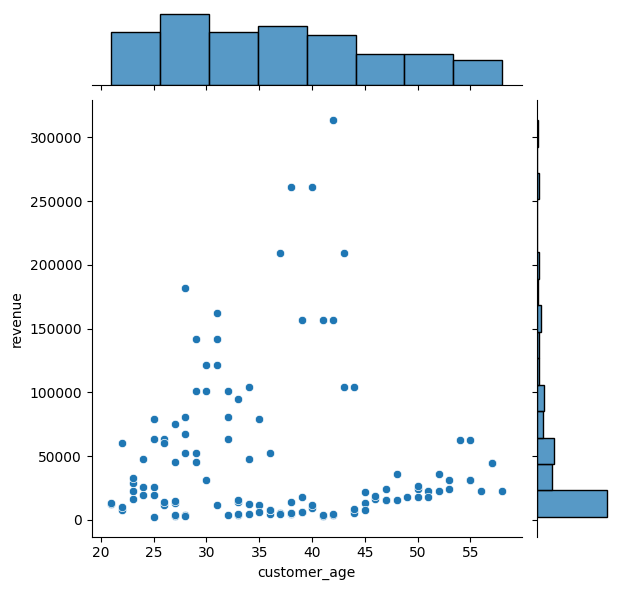

In [17]:
sns.jointplot(x='customer_age', y='revenue', data=df, kind='scatter')
plt.show()

##### This the joint plot, where the age is scattered against the expenses that they'd made, also with the frequency distribution of how densely, the people are in their age range and revenue is in its expenses range...

#### Question 13: Pairplot

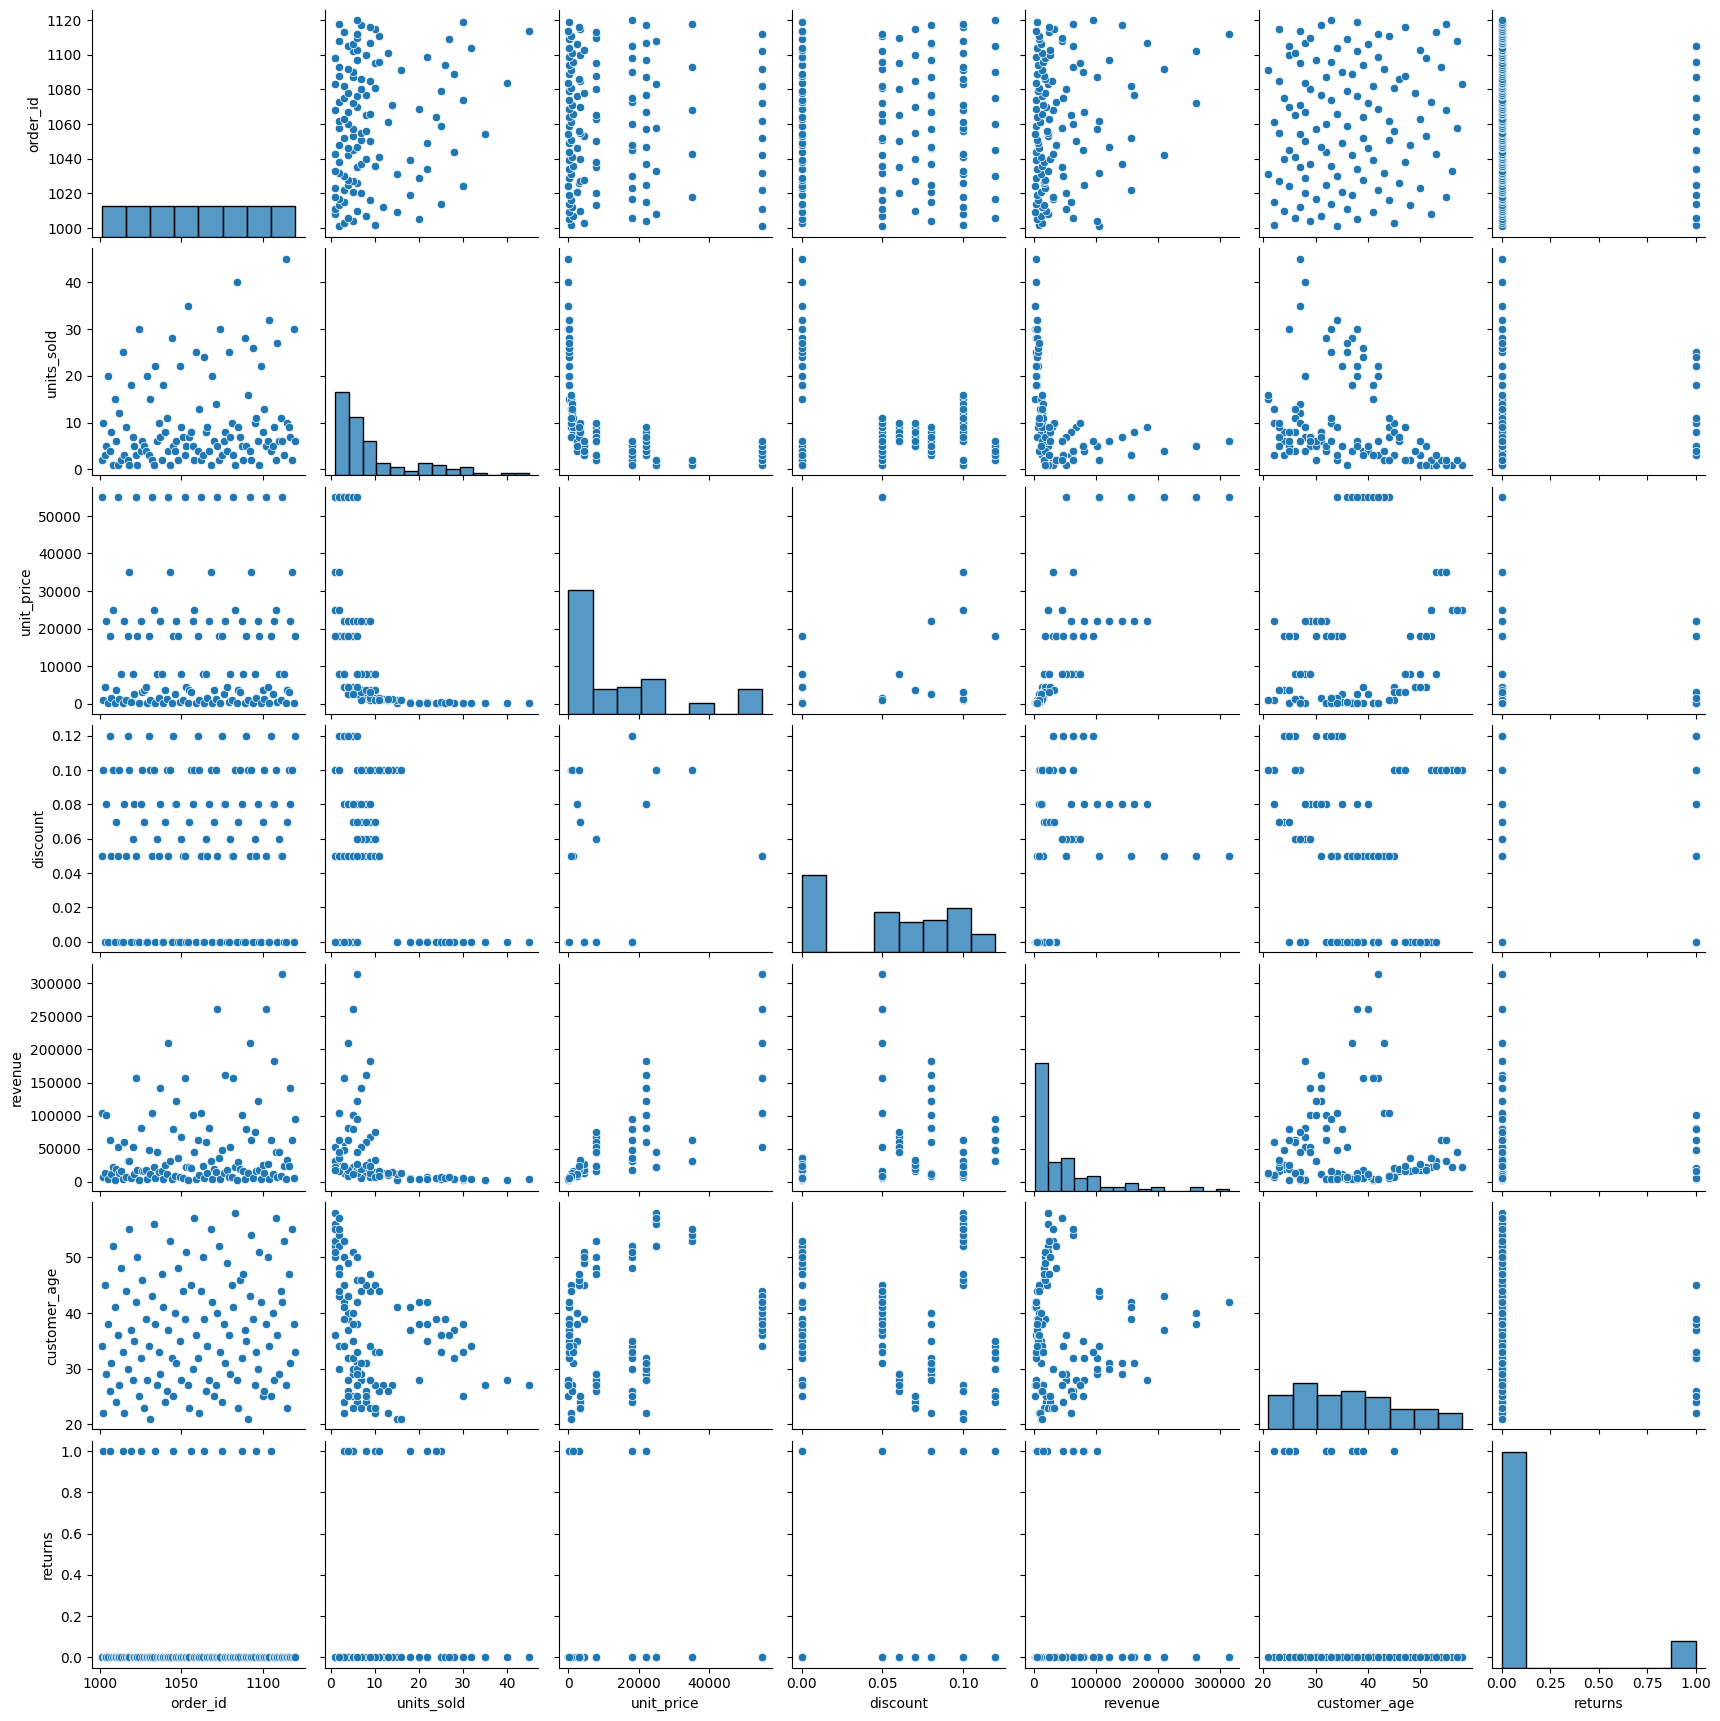

In [18]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.show()

##### This pair plot is to rough get the estimate of how every data feature is scattered against other feature of the data (in scatter plots) and then each feature is also having its own frequency distribution chart...

#### Question 14: Heatmap

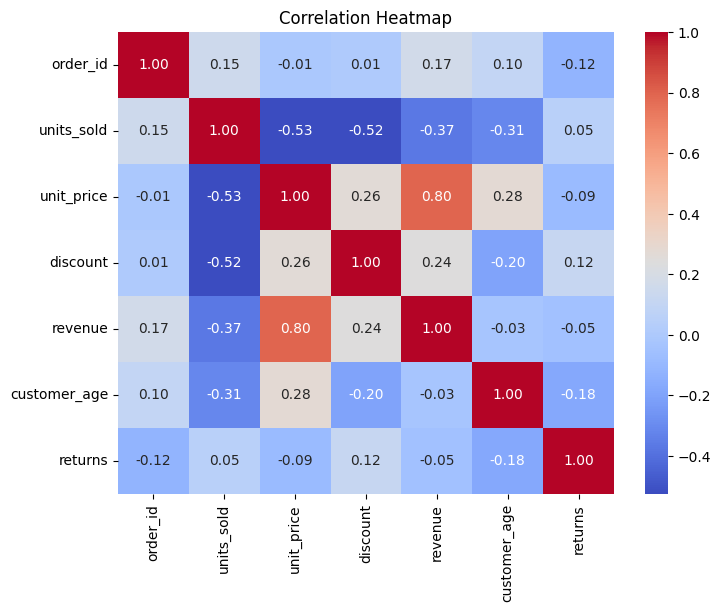

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##### This is the Heatmap of all the numeric values and how deeply are the correlated to other numeric feature... This gives us the idea how does one feature can deeply affect the other feature...